<a href="https://colab.research.google.com/github/m-soumitha/Disease-Cooccurrence-Pattern-Mining/blob/main/research_internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Connect Google Drive to Colab
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive connected successfully!")

Mounted at /content/drive
Google Drive connected successfully!


In [ ]:
# Step 2: Load the dataset
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Internship_Project/Datasets/U.S._Chronic_Disease_Indicators.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Shape: (309215, 34)
Rows: 309215
Columns: 34


In [ ]:
# Step 3: See first 5 rows
df.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2019,2019,AR,Arkansas,BRFSS,Diabetes,Diabetes among adults,NaN,%,Crude Prevalence,...,DIA,DIA01,NaN,CRDPREV,SEX,SEXM,NaN,NaN,NaN,NaN
1,2019,2019,ID,Idaho,BRFSS,Diabetes,Diabetes among adults,NaN,%,Crude Prevalence,...,DIA,DIA01,NaN,CRDPREV,SEX,SEXM,NaN,NaN,NaN,NaN
2,2019,2019,IN,Indiana,YRBSS,Sleep,Short sleep duration among high school students,NaN,%,Crude Prevalence,...,SLEP,SLP02,NaN,CRDPREV,GRADE,GRD12,NaN,NaN,NaN,NaN
3,2019,2019,IA,Iowa,NVSS,Asthma,"Asthma mortality among all people, underlying ...",NaN,Number,Number,...,AST,AST01,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
4,2019,2019,IA,Iowa,BRFSS,Asthma,Current asthma among adults,NaN,%,Crude Prevalence,...,AST,AST02,NaN,CRDPREV,AGE,AGE1844,NaN,NaN,NaN,NaN


In [ ]:
# Step 4: See all column names
print("Column names:")
for col in df.columns:
    print(" →", col)

Column names:
 → YearStart
 → YearEnd
 → LocationAbbr
 → LocationDesc
 → DataSource
 → Topic
 → Question
 → Response
 → DataValueUnit
 → DataValueType
 → DataValue
 → DataValueAlt
 → DataValueFootnoteSymbol
 → DataValueFootnote
 → LowConfidenceLimit
 → HighConfidenceLimit
 → StratificationCategory1
 → Stratification1
 → StratificationCategory2
 → Stratification2
 → StratificationCategory3
 → Stratification3
 → Geolocation
 → LocationID
 → TopicID
 → QuestionID
 → ResponseID
 → DataValueTypeID
 → StratificationCategoryID1
 → StratificationID1
 → StratificationCategoryID2
 → StratificationID2
 → StratificationCategoryID3
 → StratificationID3


In [ ]:
# See what disease topics are in this dataset
print("Unique disease topics:")
print(df['Topic'].unique())
print("\nTotal unique topics:", df['Topic'].nunique())

Unique disease topics:
['Diabetes' 'Sleep' 'Asthma' 'Health Status' 'Mental Health' 'Alcohol'
 'Arthritis' 'Tobacco' 'Disability' 'Immunization' 'Oral Health'
 'Nutrition, Physical Activity, and Weight Status' 'Cancer'
 'Cardiovascular Disease' 'Chronic Obstructive Pulmonary Disease'
 'Cognitive Health and Caregiving' 'Social Determinants of Health'
 'Maternal Health' 'Chronic Kidney Disease']

Total unique topics: 19


In [ ]:
# Check how many rows we have per topic
print(df['Topic'].value_counts())

Topic
Cardiovascular Disease                             30709
Chronic Obstructive Pulmonary Disease              26951
Nutrition, Physical Activity, and Weight Status    26069
Health Status                                      25612
Alcohol                                            25321
Cancer                                             22358
Immunization                                       19140
Social Determinants of Health                      19026
Arthritis                                          18645
Diabetes                                           17318
Mental Health                                      16976
Tobacco                                            15931
Oral Health                                        13236
Asthma                                             10511
Cognitive Health and Caregiving                     9904
Sleep                                               5318
Disability                                          5060
Maternal Health          

In [ ]:
# Step: Check missing values
print("Missing values in each column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())
print("Total rows:", len(df))

Missing values in each column:
YearStart                         0
YearEnd                           0
LocationAbbr                      0
LocationDesc                      0
DataSource                        0
Topic                             0
Question                          0
Response                     309215
DataValueUnit                     0
DataValueType                     0
DataValue                    100019
DataValueAlt                 100019
DataValueFootnoteSymbol      207499
DataValueFootnote            207499
LowConfidenceLimit           120330
HighConfidenceLimit          120325
StratificationCategory1           0
Stratification1                   0
StratificationCategory2      309215
Stratification2              309215
StratificationCategory3      309215
Stratification3              309215
Geolocation                    5763
LocationID                        0
TopicID                           0
QuestionID                        0
ResponseID                   3092

In [ ]:
# Check which dataset is currently loaded
print("Current dataset columns:")
print(df.columns.tolist())
print("\nShape:", df.shape)
print("\nFirst column values sample:")
print(df.iloc[0])

Current dataset columns:
['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'DataSource', 'Topic', 'Question', 'Response', 'DataValueUnit', 'DataValueType', 'DataValue', 'DataValueAlt', 'DataValueFootnoteSymbol', 'DataValueFootnote', 'LowConfidenceLimit', 'HighConfidenceLimit', 'StratificationCategory1', 'Stratification1', 'StratificationCategory2', 'Stratification2', 'StratificationCategory3', 'Stratification3', 'Geolocation', 'LocationID', 'TopicID', 'QuestionID', 'ResponseID', 'DataValueTypeID', 'StratificationCategoryID1', 'StratificationID1', 'StratificationCategoryID2', 'StratificationID2', 'StratificationCategoryID3', 'StratificationID3']

Shape: (309215, 34)

First column values sample:
YearStart                                                            2019
YearEnd                                                              2019
LocationAbbr                                                           AR
LocationDesc                                                     Ark

In [ ]:
# Load Kaggle dataset with a DIFFERENT variable name
# so we don't confuse the two datasets
df_kaggle = pd.read_csv('/content/drive/MyDrive/Internship_Project/Datasets/diagnoses.csv')

print("Kaggle dataset loaded!")
print("Shape:", df_kaggle.shape)
df_kaggle.head()

Kaggle dataset loaded!
Shape: (274592, 8)


,patient_id,visit_date,visit_type,primary_diagnosis,primary_icd10,secondary_diagnoses,secondary_icd10s,provider_specialty
0,P0000001,2018-07-26,telehealth,hyperlipidemia,E78.5,chronic_kidney_disease,N18.3,internal_medicine
1,P0000001,2020-04-09,outpatient,hyperlipidemia,E78.5,chronic_kidney_disease|osteoarthritis,N18.3|M19.90,nephrology
2,P0000001,2023-08-12,emergency,chronic_kidney_disease,N18.3,hyperlipidemia,E78.5,internal_medicine
3,P0000001,2022-11-04,outpatient,osteoarthritis,M19.90,hyperlipidemia|chronic_kidney_disease,E78.5|N18.3,internal_medicine
4,P0000002,2020-07-29,outpatient,osteoarthritis,M19.90,type2_diabetes,E11.9,nephrology


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Load diagnoses dataset
df_diagnoses = pd.read_csv('/content/drive/MyDrive/Internship_Project/Datasets/Kaggle_Patient_Records/diagnoses.csv')

print("✅ Diagnoses dataset loaded!")
print("Rows:", df_diagnoses.shape[0])
print("Columns:", df_diagnoses.shape[1])
print("\nColumn names:")
for col in df_diagnoses.columns:
    print(" →", col)

✅ Diagnoses dataset loaded!
Rows: 274592
Columns: 8

Column names:
 → patient_id
 → visit_date
 → visit_type
 → primary_diagnosis
 → primary_icd10
 → secondary_diagnoses
 → secondary_icd10s
 → provider_specialty


In [ ]:
# Load patients dataset
df_patients = pd.read_csv('/content/drive/MyDrive/Internship_Project/Datasets/Kaggle_Patient_Records/patients.csv')

print("✅ Patients dataset loaded!")
print("Rows:", df_patients.shape[0])
print("Columns:", df_patients.shape[1])
print("\nColumn names:")
for col in df_patients.columns:
    print(" →", col)

✅ Patients dataset loaded!
Rows: 100000
Columns: 28

Column names:
 → patient_id
 → age
 → sex
 → bmi
 → systolic_bp
 → diastolic_bp
 → heart_rate
 → temperature_f
 → smoking_status
 → alcohol_use
 → exercise_level
 → insurance_type
 → charlson_index
 → dx_hypertension
 → dx_type2_diabetes
 → dx_hyperlipidemia
 → dx_obesity
 → dx_coronary_artery_disease
 → dx_heart_failure
 → dx_atrial_fibrillation
 → dx_chronic_kidney_disease
 → dx_copd
 → dx_asthma
 → dx_depression
 → dx_anxiety
 → dx_hypothyroidism
 → dx_osteoarthritis
 → dx_type1_diabetes


In [ ]:
# See first 10 rows of diagnoses
print("First 10 rows of diagnoses:")
df_diagnoses.head(10)

First 10 rows of diagnoses:


,patient_id,visit_date,visit_type,primary_diagnosis,primary_icd10,secondary_diagnoses,secondary_icd10s,provider_specialty
0,P0000001,2018-07-26,telehealth,hyperlipidemia,E78.5,chronic_kidney_disease,N18.3,internal_medicine
1,P0000001,2020-04-09,outpatient,hyperlipidemia,E78.5,chronic_kidney_disease|osteoarthritis,N18.3|M19.90,nephrology
2,P0000001,2023-08-12,emergency,chronic_kidney_disease,N18.3,hyperlipidemia,E78.5,internal_medicine
3,P0000001,2022-11-04,outpatient,osteoarthritis,M19.90,hyperlipidemia|chronic_kidney_disease,E78.5|N18.3,internal_medicine
4,P0000002,2020-07-29,outpatient,osteoarthritis,M19.90,type2_diabetes,E11.9,nephrology
5,P0000002,2018-10-18,outpatient,type2_diabetes,E11.9,obesity|asthma,E66.9|J45.909,nephrology
6,P0000002,2023-04-03,outpatient,hypertension,I10,osteoarthritis|asthma,M19.90|J45.909,internal_medicine
7,P0000002,2018-06-07,outpatient,hypertension,I10,asthma|obesity,J45.909|E66.9,endocrinology
8,P0000002,2023-10-12,outpatient,hypertension,I10,obesity,E66.9,family_medicine
9,P0000002,2021-10-17,telehealth,osteoarthritis,M19.90,hypertension|type2_diabetes,I10|E11.9,family_medicine


First 10 rows of patients:


,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,heart_rate,temperature_f,smoking_status,alcohol_use,...,dx_heart_failure,dx_atrial_fibrillation,dx_chronic_kidney_disease,dx_copd,dx_asthma,dx_depression,dx_anxiety,dx_hypothyroidism,dx_osteoarthritis,dx_type1_diabetes
0,P0000001,66,M,23.5,148,81,64,98.4,former,light,...,0,0,1,0,0,0,0,0,1,0
1,P0000002,75,M,24.8,158,86,45,99.5,never,moderate,...,0,0,0,0,1,0,0,0,1,0
2,P0000003,82,M,17.8,135,57,90,98.2,never,light,...,0,0,1,0,0,0,0,0,0,0
3,P0000004,73,F,28.1,118,83,102,98.9,former,moderate,...,0,0,0,0,0,0,0,0,0,0
4,P0000005,86,F,30.6,156,81,56,98.7,never,heavy,...,0,0,0,0,1,1,0,1,0,0
5,P0000006,91,F,29.7,135,94,67,98.4,never,moderate,...,0,0,0,0,0,1,0,0,0,0
6,P0000007,74,M,24.5,125,67,83,98.6,current,light,...,0,0,0,1,0,0,1,0,0,0
7,P0000008,56,F,18.9,118,89,78,99.6,former,none,...,0,1,0,1,0,0,1,0,0,0
8,P0000009,86,F,24.0,159,64,74,98.4,current,light,...,0,0,0,0,0,0,0,0,0,0
9,P0000010,95,F,29.0,150,114,45,98.9,former,moderate,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
# Check missing values in patients dataset
print("Missing values in patients dataset:")
print(df_patients.isnull().sum())
print("\nTotal missing values:", df_patients.isnull().sum().sum())

Missing values in patients dataset:
patient_id                    0
age                           0
sex                           0
bmi                           0
systolic_bp                   0
diastolic_bp                  0
heart_rate                    0
temperature_f                 0
smoking_status                0
alcohol_use                   0
exercise_level                0
insurance_type                0
charlson_index                0
dx_hypertension               0
dx_type2_diabetes             0
dx_hyperlipidemia             0
dx_obesity                    0
dx_coronary_artery_disease    0
dx_heart_failure              0
dx_atrial_fibrillation        0
dx_chronic_kidney_disease     0
dx_copd                       0
dx_asthma                     0
dx_depression                 0
dx_anxiety                    0
dx_hypothyroidism             0
dx_osteoarthritis             0
dx_type1_diabetes             0
dtype: int64

Total missing values: 0


In [ ]:
# Extract only the disease columns (dx_ columns)
disease_columns = [col for col in df_patients.columns if col.startswith('dx_')]
print("Disease columns found:")
for col in disease_columns:
    print(" →", col)
print(f"\nTotal diseases: {len(disease_columns)}")

Disease columns found:
 → dx_hypertension
 → dx_type2_diabetes
 → dx_hyperlipidemia
 → dx_obesity
 → dx_coronary_artery_disease
 → dx_heart_failure
 → dx_atrial_fibrillation
 → dx_chronic_kidney_disease
 → dx_copd
 → dx_asthma
 → dx_depression
 → dx_anxiety
 → dx_hypothyroidism
 → dx_osteoarthritis
 → dx_type1_diabetes

Total diseases: 15


In [ ]:
# Count patients with each disease
print("Number of patients with each disease:")
print("="*50)
for col in disease_columns:
    count = df_patients[col].sum()
    percentage = round(count/len(df_patients)*100, 1)
    print(f"{col}: {count} patients ({percentage}%)")

Number of patients with each disease:
dx_hypertension: 67685 patients (67.7%)
dx_type2_diabetes: 15750 patients (15.8%)
dx_hyperlipidemia: 54534 patients (54.5%)
dx_obesity: 60309 patients (60.3%)
dx_coronary_artery_disease: 9995 patients (10.0%)
dx_heart_failure: 2859 patients (2.9%)
dx_atrial_fibrillation: 2905 patients (2.9%)
dx_chronic_kidney_disease: 21481 patients (21.5%)
dx_copd: 8450 patients (8.5%)
dx_asthma: 11568 patients (11.6%)
dx_depression: 12819 patients (12.8%)
dx_anxiety: 11484 patients (11.5%)
dx_hypothyroidism: 7193 patients (7.2%)
dx_osteoarthritis: 18633 patients (18.6%)
dx_type1_diabetes: 716 patients (0.7%)


In [ ]:
# Install the library needed for FP-Growth
!pip install mlxtend
print("mlxtend installed successfully!")

✅ mlxtend installed successfully!


In [ ]:
# Extract only disease columns for mining
df_mining = df_patients[disease_columns].copy()

# Convert to boolean (required by mlxtend)
df_mining = df_mining.astype(bool)

print("✅ Data prepared for mining!")
print("Shape:", df_mining.shape)
print("Ready to run FP-Growth on", len(df_mining), "patients!")

✅ Data prepared for mining!
Shape: (100000, 15)
Ready to run FP-Growth on 100000 patients!


In [ ]:
from mlxtend.frequent_patterns import fpgrowth

# Run FP-Growth algorithm
# min_support=0.1 means pattern must appear in at least 10% of patients
frequent_patterns = fpgrowth(df_mining,
                              min_support=0.1,
                              use_colnames=True)

# Sort by support (most frequent first)
frequent_patterns = frequent_patterns.sort_values('support', ascending=False)

print("✅ FP-Growth completed!")
print(f"Total frequent patterns found: {len(frequent_patterns)}")
print("\nTop 20 most frequent disease patterns:")
print(frequent_patterns.head(20))

✅ FP-Growth completed!
Total frequent patterns found: 22

Top 20 most frequent disease patterns:
    support                                          itemsets
3   0.67685                                 (dx_hypertension)
4   0.60309                                      (dx_obesity)
0   0.54534                               (dx_hyperlipidemia)
19  0.43215                     (dx_obesity, dx_hypertension)
9   0.39028              (dx_hyperlipidemia, dx_hypertension)
10  0.34870                   (dx_hyperlipidemia, dx_obesity)
11  0.26072  (dx_hyperlipidemia, dx_hypertension, dx_obesity)
1   0.21481                       (dx_chronic_kidney_disease)
2   0.18633                               (dx_osteoarthritis)
5   0.15750                               (dx_type2_diabetes)
14  0.15302      (dx_hypertension, dx_chronic_kidney_disease)
13  0.13725           (dx_obesity, dx_chronic_kidney_disease)
17  0.13250              (dx_osteoarthritis, dx_hypertension)
7   0.12819                        

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from mlxtend.frequent_patterns import association_rules

# Generate association rules
rules = association_rules(frequent_patterns,
                         metric='confidence',
                         min_threshold=0.5,
                         num_itemsets=len(frequent_patterns))

# Sort by confidence
rules = rules.sort_values('confidence', ascending=False)

print("✅ Association Rules Generated!")
print(f"Total rules found: {len(rules)}")
print("\nTop 15 strongest rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

✅ Association Rules Generated!
Total rules found: 19

Top 15 strongest rules:
                                     antecedents          consequents  \
7                (dx_hyperlipidemia, dx_obesity)    (dx_hypertension)   
16       (dx_obesity, dx_chronic_kidney_disease)    (dx_hypertension)   
0                                   (dx_obesity)    (dx_hypertension)   
2                            (dx_hyperlipidemia)    (dx_hypertension)   
9                    (dx_chronic_kidney_disease)    (dx_hypertension)   
11                           (dx_osteoarthritis)    (dx_hypertension)   
14                           (dx_type2_diabetes)    (dx_hypertension)   
6           (dx_hyperlipidemia, dx_hypertension)         (dx_obesity)   
17  (dx_hypertension, dx_chronic_kidney_disease)         (dx_obesity)   
4                            (dx_hyperlipidemia)         (dx_obesity)   
10                   (dx_chronic_kidney_disease)         (dx_obesity)   
18                           (dx_type2_diabete

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Filter strongest rules - high confidence AND high lift
strong_rules = rules[(rules['confidence'] >= 0.6) & (rules['lift'] >= 1.2)]
strong_rules = strong_rules.sort_values('lift', ascending=False)

print(f"Strong rules found: {len(strong_rules)}")
print("\nYour strongest disease associations:")
print(strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Strong rules found: 0

Your strongest disease associations:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Save results to Google Drive
frequent_patterns.to_csv('/content/drive/MyDrive/Internship_Project/Results/frequent_patterns.csv', index=False)
rules.to_csv('/content/drive/MyDrive/Internship_Project/Results/association_rules.csv', index=False)
strong_rules.to_csv('/content/drive/MyDrive/Internship_Project/Results/strong_rules.csv', index=False)

print("✅ All results saved to Google Drive!")
print("Files saved:")
print(" → frequent_patterns.csv")
print(" → association_rules.csv")
print(" → strong_rules.csv")

✅ All results saved to Google Drive!
Files saved:
 → frequent_patterns.csv
 → association_rules.csv
 → strong_rules.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Lower the lift threshold - your data has lift around 1.05-1.11
# This is normal and still meaningful
strong_rules = rules[(rules['confidence'] >= 0.6) &
                     (rules['lift'] >= 1.0)]
strong_rules = strong_rules.sort_values('confidence', ascending=False)

print(f"Strong rules found: {len(strong_rules)}")
print("\nYour strongest disease associations:")
print(strong_rules[['antecedents', 'consequents',
                     'support', 'confidence', 'lift']].to_string())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Strong rules found: 15

Your strongest disease associations:
                                     antecedents          consequents  support  confidence      lift
7                (dx_hyperlipidemia, dx_obesity)    (dx_hypertension)  0.26072    0.747691  1.104663
16       (dx_obesity, dx_chronic_kidney_disease)    (dx_hypertension)  0.10207    0.743679  1.098736
0                                   (dx_obesity)    (dx_hypertension)  0.43215    0.716560  1.058668
2                            (dx_hyperlipidemia)    (dx_hypertension)  0.39028    0.715664  1.057344
9                    (dx_chronic_kidney_disease)    (dx_hypertension)  0.15302    0.712350  1.052450
11                           (dx_osteoarthritis)    (dx_hypertension)  0.13250    0.711104  1.050608
14                           (dx_type2_diabetes)    (dx_hypertension)  0.11173    0.709397  1.048086
6           (dx_hyperlipidemia, dx_hypertension)         (dx_obesity)  0.26072    0.668033  1.107684
17  (dx_hypertension, dx_chron

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Write plain English interpretation of top rules
print("="*60)
print("RESEARCH FINDINGS — PLAIN ENGLISH INTERPRETATION")
print("="*60)

for idx, row in strong_rules.head(10).iterrows():
    ant = list(row['antecedents'])
    con = list(row['consequents'])
    conf = round(row['confidence']*100, 1)
    sup = round(row['support']*100, 1)
    lift = round(row['lift'], 3)

    print(f"\nRule: IF patient has {ant}")
    print(f"      THEN they likely also have {con}")
    print(f"      Confidence: {conf}% | Support: {sup}% | Lift: {lift}")
    print(f"      Meaning: {conf}% of patients with {ant} also have {con}")
    print("-"*60)

RESEARCH FINDINGS — PLAIN ENGLISH INTERPRETATION

Rule: IF patient has ['dx_hyperlipidemia', 'dx_obesity']
      THEN they likely also have ['dx_hypertension']
      Confidence: 74.8% | Support: 26.1% | Lift: 1.105
      Meaning: 74.8% of patients with ['dx_hyperlipidemia', 'dx_obesity'] also have ['dx_hypertension']
------------------------------------------------------------

Rule: IF patient has ['dx_obesity', 'dx_chronic_kidney_disease']
      THEN they likely also have ['dx_hypertension']
      Confidence: 74.4% | Support: 10.2% | Lift: 1.099
      Meaning: 74.4% of patients with ['dx_obesity', 'dx_chronic_kidney_disease'] also have ['dx_hypertension']
------------------------------------------------------------

Rule: IF patient has ['dx_obesity']
      THEN they likely also have ['dx_hypertension']
      Confidence: 71.7% | Support: 43.2% | Lift: 1.059
      Meaning: 71.7% of patients with ['dx_obesity'] also have ['dx_hypertension']
---------------------------------------------

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

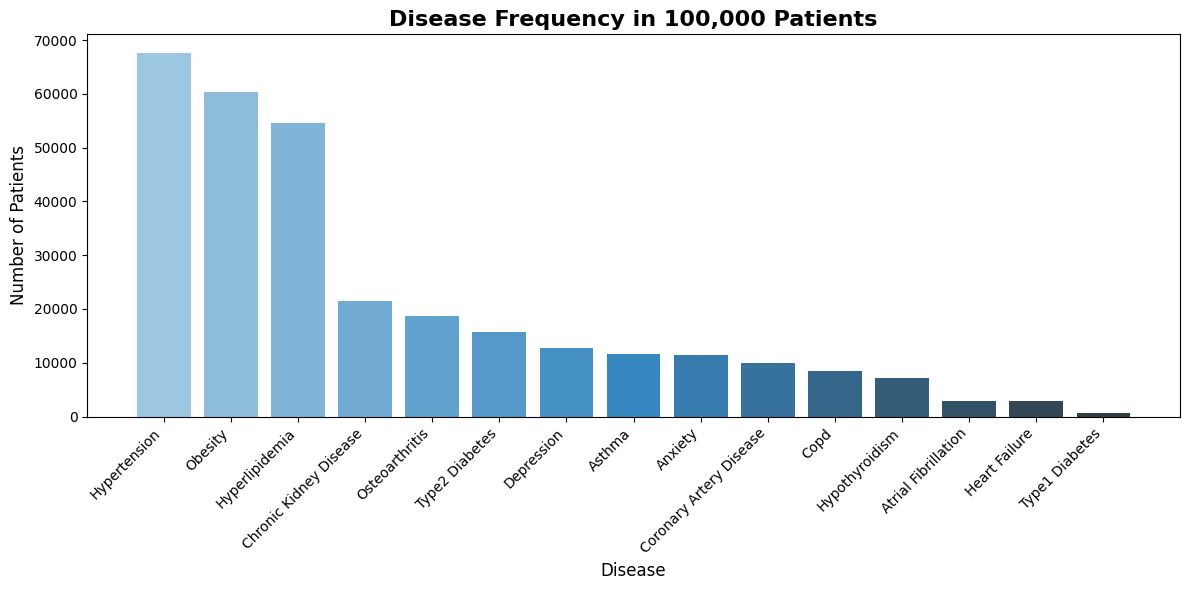

✅ Chart saved!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Disease frequency chart
disease_counts = df_patients[disease_columns].sum().sort_values(ascending=False)
disease_names = [col.replace('dx_', '').replace('_', ' ').title()
                 for col in disease_counts.index]

plt.figure(figsize=(12, 6))
bars = plt.bar(disease_names, disease_counts.values,
               color=sns.color_palette("Blues_d", len(disease_names)))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Disease Frequency in 100,000 Patients', fontsize=16, fontweight='bold')
plt.ylabel('Number of Patients', fontsize=12)
plt.xlabel('Disease', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Internship_Project/Results/disease_frequency.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

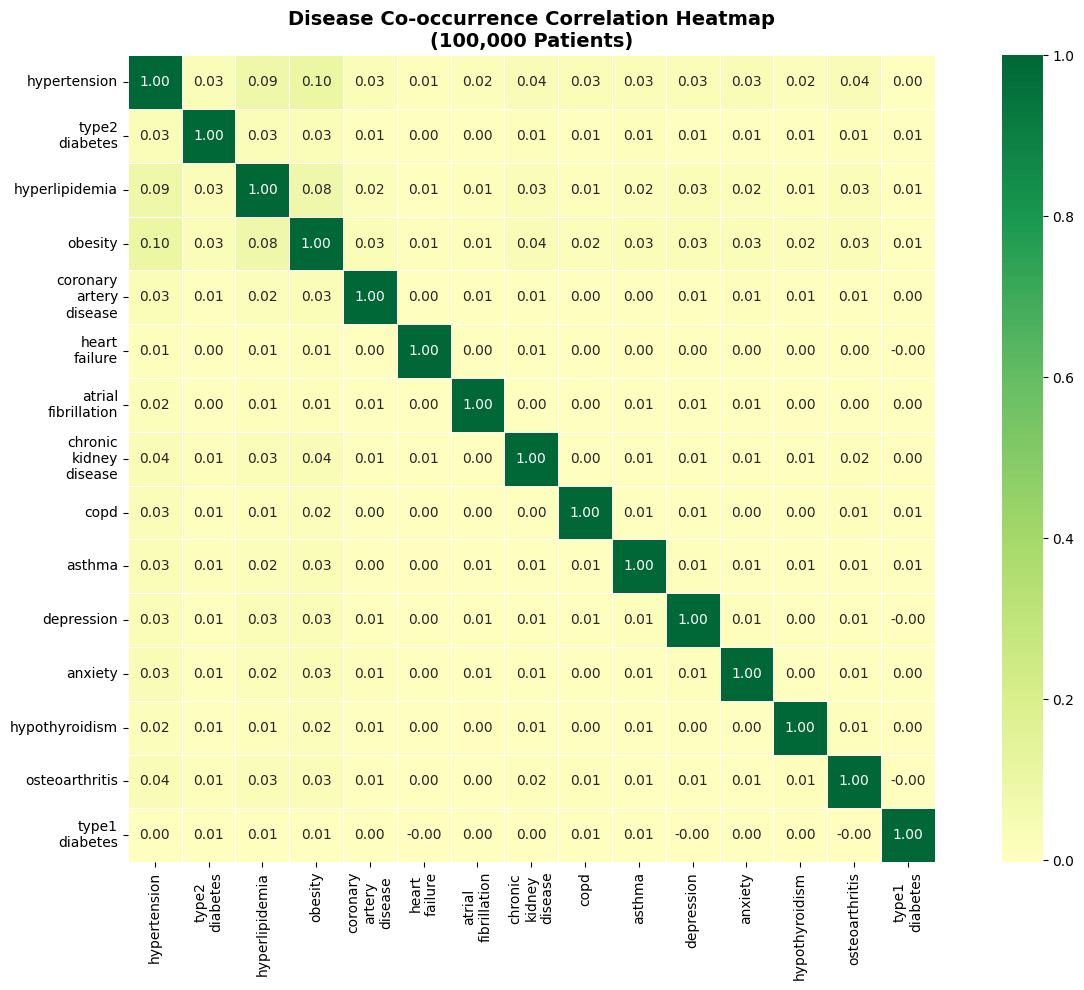

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Heatmap saved!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
disease_data = df_patients[disease_columns]
correlation_matrix = disease_data.corr()

clean_names = [col.replace('dx_', '').replace('_', '\n') for col in disease_columns]
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            xticklabels=clean_names,
            yticklabels=clean_names,
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Disease Co-occurrence Correlation Heatmap\n(100,000 Patients)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Internship_Project/Results/correlation_heatmap.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved!")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

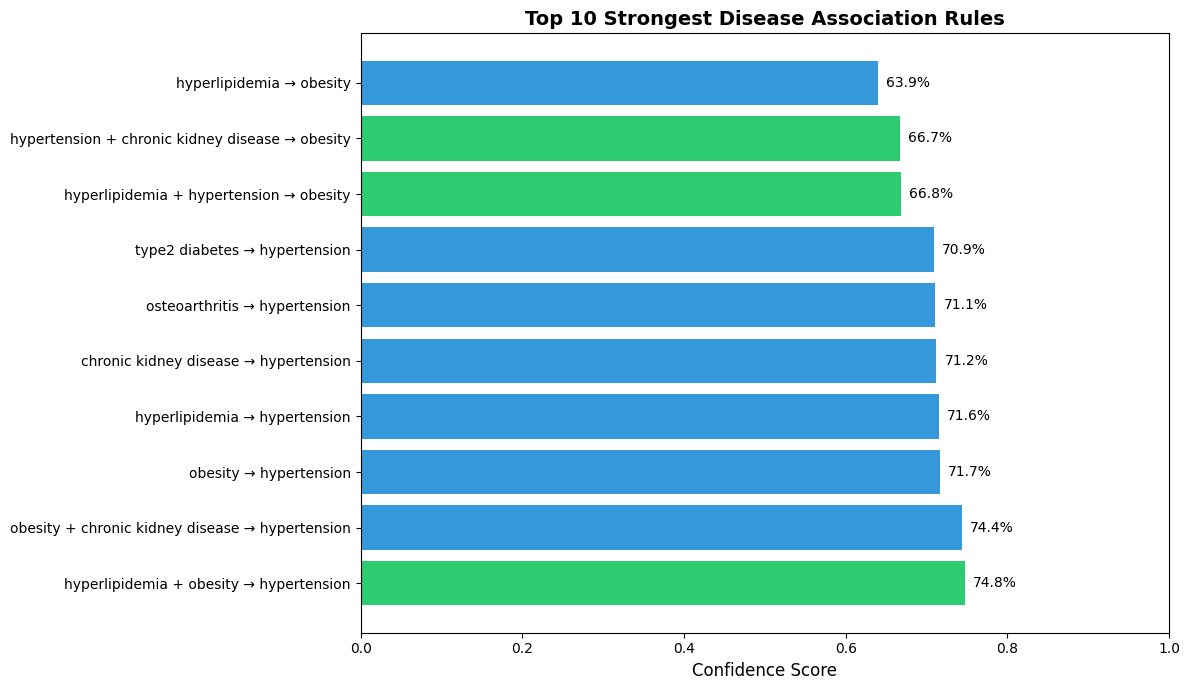

✅ Rules chart saved!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Top rules visualization
top_rules = strong_rules.head(10).copy()
rule_labels = []
for idx, row in top_rules.iterrows():
    ant = ' + '.join([a.replace('dx_','').replace('_',' ')
                      for a in list(row['antecedents'])])
    con = ' + '.join([c.replace('dx_','').replace('_',' ')
                      for c in list(row['consequents'])])
    rule_labels.append(f"{ant} → {con}")

plt.figure(figsize=(12, 7))
colors = ['#2ecc71' if lift > 1.1 else '#3498db'
          for lift in top_rules['lift']]
bars = plt.barh(rule_labels, top_rules['confidence'].values, color=colors)
plt.xlabel('Confidence Score', fontsize=12)
plt.title('Top 10 Strongest Disease Association Rules',
          fontsize=14, fontweight='bold')
plt.xlim(0, 1)
for bar, conf in zip(bars, top_rules['confidence'].values):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{conf:.1%}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Internship_Project/Results/top_association_rules.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Rules chart saved!")

In [ ]:
# ============================================================
# WEEK 3 - NEW SECTION: CLINICAL DATASET (DIABETIC - UCI)
# Switching to real clinical data
# ============================================================
print("Starting clinical dataset analysis...")

Starting clinical dataset analysis...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive connected!")

Mounted at /content/drive
✅ Drive connected!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Internship_Project/Datasets/Clinical/diabetic_data.csv')

print("✅ Dataset loaded!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nFirst 5 rows:")
df.head()

✅ Dataset loaded!
Rows: 101766
Columns: 50

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
print("All columns in the dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

All columns in the dataset:
  1. encounter_id
  2. patient_nbr
  3. race
  4. gender
  5. age
  6. weight
  7. admission_type_id
  8. discharge_disposition_id
  9. admission_source_id
  10. time_in_hospital
  11. payer_code
  12. medical_specialty
  13. num_lab_procedures
  14. num_procedures
  15. num_medications
  16. number_outpatient
  17. number_emergency
  18. number_inpatient
  19. diag_1
  20. diag_2
  21. diag_3
  22. number_diagnoses
  23. max_glu_serum
  24. A1Cresult
  25. metformin
  26. repaglinide
  27. nateglinide
  28. chlorpropamide
  29. glimepiride
  30. acetohexamide
  31. glipizide
  32. glyburide
  33. tolbutamide
  34. pioglitazone
  35. rosiglitazone
  36. acarbose
  37. miglitol
  38. troglitazone
  39. tolazamide
  40. examide
  41. citoglipton
  42. insulin
  43. glyburide-metformin
  44. glipizide-metformin
  45. glimepiride-pioglitazone
  46. metformin-rosiglitazone
  47. metformin-pioglitazone
  48. change
  49. diabetesMed
  50. readmitted


In [ ]:
print("=== MISSING VALUE CHECK ===")
print("(? marks are used instead of NaN in this dataset)\n")

missing = {}
for col in df.columns:
    q_count = (df[col] == '?').sum()
    null_count = df[col].isnull().sum()
    total = q_count + null_count
    if total > 0:
        pct = round(total / len(df) * 100, 1)
        missing[col] = f"{total} missing ({pct}%)"
        print(f"  {col}: {total} missing ({pct}%)")

if not missing:
    print("No missing values found!")
else:
    print(f"\nTotal columns with missing values: {len(missing)}")

=== MISSING VALUE CHECK ===
(? marks are used instead of NaN in this dataset)

  race: 2273 missing (2.2%)
  weight: 98569 missing (96.9%)
  payer_code: 40256 missing (39.6%)
  medical_specialty: 49949 missing (49.1%)
  diag_1: 21 missing (0.0%)
  diag_2: 358 missing (0.4%)
  diag_3: 1423 missing (1.4%)
  max_glu_serum: 96420 missing (94.7%)
  A1Cresult: 84748 missing (83.3%)

Total columns with missing values: 9


In [ ]:
print("=== DUPLICATE CHECK ===")
total_rows = len(df)
unique_patients = df['patient_nbr'].nunique()
duplicate_encounters = total_rows - unique_patients

print(f"Total hospital encounters: {total_rows}")
print(f"Unique patients: {unique_patients}")
print(f"Patients with multiple visits: {duplicate_encounters}")
print(f"\nNote: Same patient may have visited hospital multiple times")
print(f"We will keep only the first visit per patient for mining")

=== DUPLICATE CHECK ===
Total hospital encounters: 101766
Unique patients: 71518
Patients with multiple visits: 30248

Note: Same patient may have visited hospital multiple times
We will keep only the first visit per patient for mining


In [ ]:
# Keep only first hospital encounter per patient
df_first = df.drop_duplicates(subset='patient_nbr', keep='first')

print(f"✅ Kept first visit per patient only")
print(f"Before: {len(df)} rows")
print(f"After:  {len(df_first)} rows")
print(f"Removed: {len(df) - len(df_first)} duplicate encounters")

✅ Kept first visit per patient only
Before: 101766 rows
After:  71518 rows
Removed: 30248 duplicate encounters


In [ ]:
# Drop columns with too many missing values or not useful for mining
cols_to_drop = [
    'weight',           # 97% missing
    'payer_code',       # not clinically relevant
    'medical_specialty',# too many missing
    'encounter_id',     # just an ID
]

df_clean = df_first.drop(columns=cols_to_drop)

print(f"✅ Dropped unnecessary columns")
print(f"Columns remaining: {df_clean.shape[1]}")
print(f"Patients remaining: {df_clean.shape[0]}")

✅ Dropped unnecessary columns
Columns remaining: 46
Patients remaining: 71518


In [ ]:
print("=== DIAGNOSIS COLUMNS ===")
print("These are the key columns for co-occurrence mining\n")

print("Sample of diagnosis columns:")
print(df_clean[['patient_nbr', 'diag_1', 'diag_2', 'diag_3']].head(20))

print(f"\nUnique diseases in diag_1: {df_clean['diag_1'].nunique()}")
print(f"Unique diseases in diag_2: {df_clean['diag_2'].nunique()}")
print(f"Unique diseases in diag_3: {df_clean['diag_3'].nunique()}")

=== DIAGNOSIS COLUMNS ===
These are the key columns for co-occurrence mining

Sample of diagnosis columns:
    patient_nbr  diag_1  diag_2 diag_3
0       8222157  250.83       ?      ?
1      55629189     276  250.01    255
2      86047875     648     250    V27
3      82442376       8  250.43    403
4      42519267     197     157    250
5      82637451     414     411    250
6      84259809     414     411    V45
7     114882984     428     492    250
8      48330783     398     427     38
9      63555939     434     198    486
10     89869032   250.7     403    996
11     77391171     157     288    197
12     85504905     428  250.43  250.6
13     77586282     428     411    427
14     49726791     518     998    627
15     86328819     999     507    996
16     92519352     410     411    414
17    108662661     682     174    250
18    107389323     402     425    416
19     69422211     737     427    714

Unique diseases in diag_1: 697
Unique diseases in diag_2: 726
Unique dise

In [ ]:
# ICD code to disease category mapping
# This groups hundreds of ICD codes into meaningful disease categories
def map_icd_to_disease(icd_code):
    try:
        code = str(icd_code).strip()
        if code == '?' or code == 'nan':
            return 'Unknown'

        # Handle E and V codes
        if code.startswith('E') or code.startswith('V'):
            return 'Other'

        num = float(code.split('.')[0])

        if 390 <= num <= 459 or num == 785:
            return 'Cardiovascular Disease'
        elif 460 <= num <= 519 or num == 786:
            return 'Respiratory Disease'
        elif 520 <= num <= 579 or num == 787:
            return 'Digestive Disease'
        elif 250 <= num <= 250.99:
            return 'Diabetes'
        elif 800 <= num <= 999:
            return 'Injury/Trauma'
        elif 710 <= num <= 739:
            return 'Musculoskeletal Disease'
        elif 580 <= num <= 629:
            return 'Genitourinary Disease'
        elif 140 <= num <= 239:
            return 'Cancer'
        elif 290 <= num <= 319:
            return 'Mental Health'
        elif 240 <= num <= 279:
            return 'Metabolic Disease'
        elif 280 <= num <= 289:
            return 'Blood Disease'
        elif 320 <= num <= 389:
            return 'Nervous System Disease'
        elif 680 <= num <= 709:
            return 'Skin Disease'
        elif 1 <= num <= 139:
            return 'Infectious Disease'
        else:
            return 'Other'
    except:
        return 'Unknown'

# Apply mapping to all three diagnosis columns
df_clean['disease_1'] = df_clean['diag_1'].apply(map_icd_to_disease)
df_clean['disease_2'] = df_clean['diag_2'].apply(map_icd_to_disease)
df_clean['disease_3'] = df_clean['diag_3'].apply(map_icd_to_disease)

print("✅ ICD codes mapped to disease categories!")
print("\nDisease categories found:")
all_diseases = pd.concat([
    df_clean['disease_1'],
    df_clean['disease_2'],
    df_clean['disease_3']
]).unique()
for d in sorted(all_diseases):
    print(f"  → {d}")

✅ ICD codes mapped to disease categories!

Disease categories found:
  → Blood Disease
  → Cancer
  → Cardiovascular Disease
  → Diabetes
  → Digestive Disease
  → Genitourinary Disease
  → Infectious Disease
  → Injury/Trauma
  → Mental Health
  → Metabolic Disease
  → Musculoskeletal Disease
  → Nervous System Disease
  → Other
  → Respiratory Disease
  → Skin Disease
  → Unknown


In [ ]:
# Get all unique disease categories (excluding Unknown and Other)
disease_categories = [
    'Cardiovascular Disease',
    'Respiratory Disease',
    'Digestive Disease',
    'Diabetes',
    'Musculoskeletal Disease',
    'Genitourinary Disease',
    'Cancer',
    'Mental Health',
    'Metabolic Disease',
    'Nervous System Disease',
    'Infectious Disease',
    'Blood Disease'
]

# Create binary columns for each disease category
for disease in disease_categories:
    col_name = 'dx_' + disease.lower().replace(' ', '_')
    df_clean[col_name] = (
        (df_clean['disease_1'] == disease) |
        (df_clean['disease_2'] == disease) |
        (df_clean['disease_3'] == disease)
    ).astype(int)

print("✅ Binary disease columns created!")
dx_cols = [col for col in df_clean.columns if col.startswith('dx_')]
print(f"\nTotal disease columns: {len(dx_cols)}")
print("\nDisease columns created:")
for col in dx_cols:
    count = df_clean[col].sum()
    pct = round(count/len(df_clean)*100, 1)
    print(f"  {col}: {count} patients ({pct}%)")

✅ Binary disease columns created!

Total disease columns: 12

Disease columns created:
  dx_cardiovascular_disease: 41661 patients (58.3%)
  dx_respiratory_disease: 18124 patients (25.3%)
  dx_digestive_disease: 9891 patients (13.8%)
  dx_diabetes: 27805 patients (38.9%)
  dx_musculoskeletal_disease: 5888 patients (8.2%)
  dx_genitourinary_disease: 11134 patients (15.6%)
  dx_cancer: 4456 patients (6.2%)
  dx_mental_health: 4582 patients (6.4%)
  dx_metabolic_disease: 13147 patients (18.4%)
  dx_nervous_system_disease: 2928 patients (4.1%)
  dx_infectious_disease: 4226 patients (5.9%)
  dx_blood_disease: 4395 patients (6.1%)


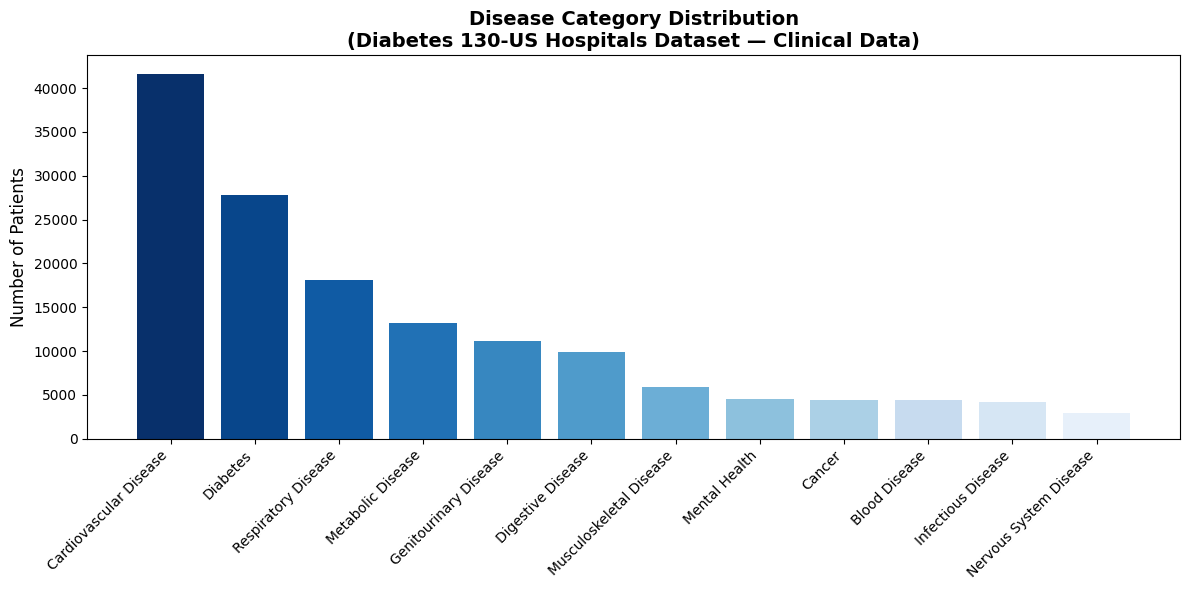

✅ Chart saved!


In [ ]:
dx_cols = [col for col in df_clean.columns if col.startswith('dx_')]
disease_counts = df_clean[dx_cols].sum().sort_values(ascending=False)
disease_labels = [col.replace('dx_','').replace('_',' ').title() for col in disease_counts.index]

plt.figure(figsize=(12, 6))
bars = plt.bar(disease_labels, disease_counts.values, color=plt.cm.Blues_r(
    [i/len(disease_labels) for i in range(len(disease_labels))]
))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Disease Category Distribution\n(Diabetes 130-US Hospitals Dataset — Clinical Data)',
          fontsize=14, fontweight='bold')
plt.ylabel('Number of Patients', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Internship_Project/Results/clinical_disease_frequency.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [ ]:
# Save the cleaned dataset
df_clean.to_csv(
    '/content/drive/MyDrive/Internship_Project/Datasets/Clinical/diabetic_clinical_cleaned.csv',
    index=False
)

print("✅ Cleaned dataset saved!")
print(f"\nFinal dataset summary:")
print(f"  Patients: {len(df_clean)}")
print(f"  Total columns: {df_clean.shape[1]}")
print(f"  Disease columns (dx_): {len([c for c in df_clean.columns if c.startswith('dx_')])}")
print(f"  Missing values: {df_clean.isnull().sum().sum()}")
print(f"\nSaved to: Internship_Project/Datasets/Clinical/diabetic_clinical_cleaned.csv")

✅ Cleaned dataset saved!

Final dataset summary:
  Patients: 71518
  Total columns: 61
  Disease columns (dx_): 12
  Missing values: 126594

Saved to: Internship_Project/Datasets/Clinical/diabetic_clinical_cleaned.csv


In [ ]:
# Check which columns have missing values
print("Columns with missing values:")
missing = df_clean.isnull().sum()
missing = missing[missing > 0]
print(missing)
print(f"\nTotal missing: {missing.sum()}")

Columns with missing values:
max_glu_serum    68062
A1Cresult        58532
dtype: int64

Total missing: 126594


In [ ]:
# Drop columns with too many missing values
# max_glu_serum = 95% missing, A1Cresult = 81.8% missing
# These are lab test columns not needed for disease co-occurrence mining

df_clean = df_clean.drop(columns=['max_glu_serum', 'A1Cresult'])

# Verify no more missing values
remaining_missing = df_clean.isnull().sum().sum()
print(f"✅ Dropped max_glu_serum and A1Cresult columns")
print(f"Missing values remaining: {remaining_missing}")
print(f"Final shape: {df_clean.shape}")

✅ Dropped max_glu_serum and A1Cresult columns
Missing values remaining: 0
Final shape: (71518, 59)


In [ ]:
# Save final cleaned dataset
df_clean.to_csv(
    '/content/drive/MyDrive/Internship_Project/Datasets/Clinical/diabetic_clinical_cleaned.csv',
    index=False
)

# Confirm everything is ready
dx_cols = [col for col in df_clean.columns if col.startswith('dx_')]
print("✅ Final clean dataset saved!")
print(f"\nSummary:")
print(f"  Patients        : {len(df_clean)}")
print(f"  Total columns   : {df_clean.shape[1]}")
print(f"  Disease columns : {len(dx_cols)}")
print(f"  Missing values  : {df_clean.isnull().sum().sum()}")
print(f"\nDisease columns ready for FP-Growth:")
for col in dx_cols:
    count = df_clean[col].sum()
    pct = round(count/len(df_clean)*100,1)
    print(f"  {col}: {count} patients ({pct}%)")

✅ Final clean dataset saved!

Summary:
  Patients        : 71518
  Total columns   : 59
  Disease columns : 12
  Missing values  : 0

Disease columns ready for FP-Growth:
  dx_cardiovascular_disease: 41661 patients (58.3%)
  dx_respiratory_disease: 18124 patients (25.3%)
  dx_digestive_disease: 9891 patients (13.8%)
  dx_diabetes: 27805 patients (38.9%)
  dx_musculoskeletal_disease: 5888 patients (8.2%)
  dx_genitourinary_disease: 11134 patients (15.6%)
  dx_cancer: 4456 patients (6.2%)
  dx_mental_health: 4582 patients (6.4%)
  dx_metabolic_disease: 13147 patients (18.4%)
  dx_nervous_system_disease: 2928 patients (4.1%)
  dx_infectious_disease: 4226 patients (5.9%)
  dx_blood_disease: 4395 patients (6.1%)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive connected!")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Mounted at /content/drive
✅ Drive connected!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import os

path = '/content/drive/MyDrive/Internship_Project/Datasets/Clinical/diabetic_clinical_cleaned.csv'

if os.path.exists(path):
    print("✅ File found! Ready to load.")
else:
    print("❌ File not found. Checking folder...")
    # List what is in the Clinical folder
    folder = '/content/drive/MyDrive/Internship_Project/Datasets/Clinical/'
    if os.path.exists(folder):
        print("Files in Clinical folder:")
        for f in os.listdir(folder):
            print(f"  → {f}")
    else:
        print("Clinical folder does not exist!")
        print("Files in Datasets folder:")
        for f in os.listdir('/content/drive/MyDrive/Internship_Project/Datasets/'):
            print(f"  → {f}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ File found! Ready to load.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Load the cleaned clinical dataset
df_clean = pd.read_csv('/content/drive/MyDrive/Internship_Project/Datasets/Clinical/diabetic_clinical_cleaned.csv')

print("✅ Clinical dataset loaded!")
print(f"Patients: {len(df_clean)}")
print(f"Columns: {df_clean.shape[1]}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Clinical dataset loaded!
Patients: 71518
Columns: 59


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Extract only the disease columns
dx_cols = [col for col in df_clean.columns if col.startswith('dx_')]

print("Disease columns ready for mining:")
for col in dx_cols:
    count = df_clean[col].sum()
    pct = round(count/len(df_clean)*100, 1)
    print(f"  {col}: {count} patients ({pct}%)")

# Create mining dataset
df_mining = df_clean[dx_cols].copy()
df_mining = df_mining.astype(bool)

print(f"\n✅ Mining dataset ready!")
print(f"Shape: {df_mining.shape}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Disease columns ready for mining:
  dx_cardiovascular_disease: 41661 patients (58.3%)
  dx_respiratory_disease: 18124 patients (25.3%)
  dx_digestive_disease: 9891 patients (13.8%)
  dx_diabetes: 27805 patients (38.9%)
  dx_musculoskeletal_disease: 5888 patients (8.2%)
  dx_genitourinary_disease: 11134 patients (15.6%)
  dx_cancer: 4456 patients (6.2%)
  dx_mental_health: 4582 patients (6.4%)
  dx_metabolic_disease: 13147 patients (18.4%)
  dx_nervous_system_disease: 2928 patients (4.1%)
  dx_infectious_disease: 4226 patients (5.9%)
  dx_blood_disease: 4395 patients (6.1%)

✅ Mining dataset ready!
Shape: (71518, 12)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Run FP-Growth algorithm
# min_support = 0.05 means pattern must appear in 5% of patients
# Using 0.05 because some diseases are less common in clinical data

print("Running FP-Growth algorithm...")
print("This may take a few seconds...\n")

frequent_patterns = fpgrowth(
    df_mining,
    min_support=0.05,
    use_colnames=True
)

# Sort by support
frequent_patterns = frequent_patterns.sort_values(
    'support', ascending=False
).reset_index(drop=True)

print(f"✅ FP-Growth completed!")
print(f"Total frequent patterns found: {len(frequent_patterns)}")
print(f"\nTop 20 most frequent disease patterns:")
print(frequent_patterns.head(20).to_string())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Running FP-Growth algorithm...
This may take a few seconds...



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ FP-Growth completed!
Total frequent patterns found: 17

Top 20 most frequent disease patterns:
     support                                               itemsets
0   0.582525                            (dx_cardiovascular_disease)
1   0.388783                                          (dx_diabetes)
2   0.253419                               (dx_respiratory_disease)
3   0.192036               (dx_cardiovascular_disease, dx_diabetes)
4   0.183828                                 (dx_metabolic_disease)
5   0.155681                             (dx_genitourinary_disease)
6   0.138930    (dx_cardiovascular_disease, dx_respiratory_disease)
7   0.138301                                 (dx_digestive_disease)
8   0.082329                           (dx_musculoskeletal_disease)
9   0.072611                  (dx_respiratory_disease, dx_diabetes)
10  0.070709      (dx_metabolic_disease, dx_cardiovascular_disease)
11  0.069647                    (dx_metabolic_disease, dx_diabetes)
12  0.068626  (dx_c

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Generate association rules
rules = association_rules(
    frequent_patterns,
    metric='confidence',
    min_threshold=0.4,
    num_itemsets=len(frequent_patterns)
)

# Sort by confidence
rules = rules.sort_values('confidence', ascending=False).reset_index(drop=True)

print(f"✅ Association Rules Generated!")
print(f"Total rules found: {len(rules)}")
print(f"\nTop 15 strongest rules:")
print(rules[['antecedents','consequents','support','confidence','lift']].head(15).to_string())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Association Rules Generated!
Total rules found: 3

Top 15 strongest rules:
                  antecedents                  consequents   support  confidence      lift
0    (dx_respiratory_disease)  (dx_cardiovascular_disease)  0.138930    0.548223  0.941116
1               (dx_diabetes)  (dx_cardiovascular_disease)  0.192036    0.493940  0.847930
2  (dx_genitourinary_disease)  (dx_cardiovascular_disease)  0.068626    0.440812  0.756727


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print("="*65)
print("RESEARCH FINDINGS — PLAIN ENGLISH")
print("="*65)

top_rules = rules[rules['lift'] > 1.0].head(10)

for idx, row in top_rules.iterrows():
    ant = [a.replace('dx_','').replace('_',' ').title()
           for a in list(row['antecedents'])]
    con = [c.replace('dx_','').replace('_',' ').title()
           for c in list(row['consequents'])]
    conf = round(row['confidence']*100, 1)
    sup = round(row['support']*100, 1)
    lift = round(row['lift'], 3)

    print(f"\nIF patient has: {ant}")
    print(f"THEN likely also has: {con}")
    print(f"Confidence: {conf}% | Support: {sup}% | Lift: {lift}")
    print("-"*65)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

RESEARCH FINDINGS — PLAIN ENGLISH


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from mlxtend.frequent_patterns import apriori

print("Running Apriori algorithm for comparison...")

apriori_patterns = apriori(
    df_mining,
    min_support=0.05,
    use_colnames=True
)

apriori_patterns = apriori_patterns.sort_values(
    'support', ascending=False
).reset_index(drop=True)

print(f"✅ Apriori completed!")
print(f"\nComparison:")
print(f"FP-Growth patterns found: {len(frequent_patterns)}")
print(f"Apriori patterns found:   {len(apriori_patterns)}")
print(f"\nBoth should give same number of patterns.")
print(f"FP-Growth is just faster than Apriori.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Running Apriori algorithm for comparison...
✅ Apriori completed!

Comparison:
FP-Growth patterns found: 17
Apriori patterns found:   17

Both should give same number of patterns.
FP-Growth is just faster than Apriori.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Save frequent patterns
frequent_patterns.to_csv(
    '/content/drive/MyDrive/Internship_Project/Results/clinical_frequent_patterns.csv',
    index=False
)

# Save association rules
rules.to_csv(
    '/content/drive/MyDrive/Internship_Project/Results/clinical_association_rules.csv',
    index=False
)

print("✅ All results saved!")
print("\nFiles saved:")
print("  → clinical_frequent_patterns.csv")
print("  → clinical_association_rules.csv")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ All results saved!

Files saved:
  → clinical_frequent_patterns.csv
  → clinical_association_rules.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

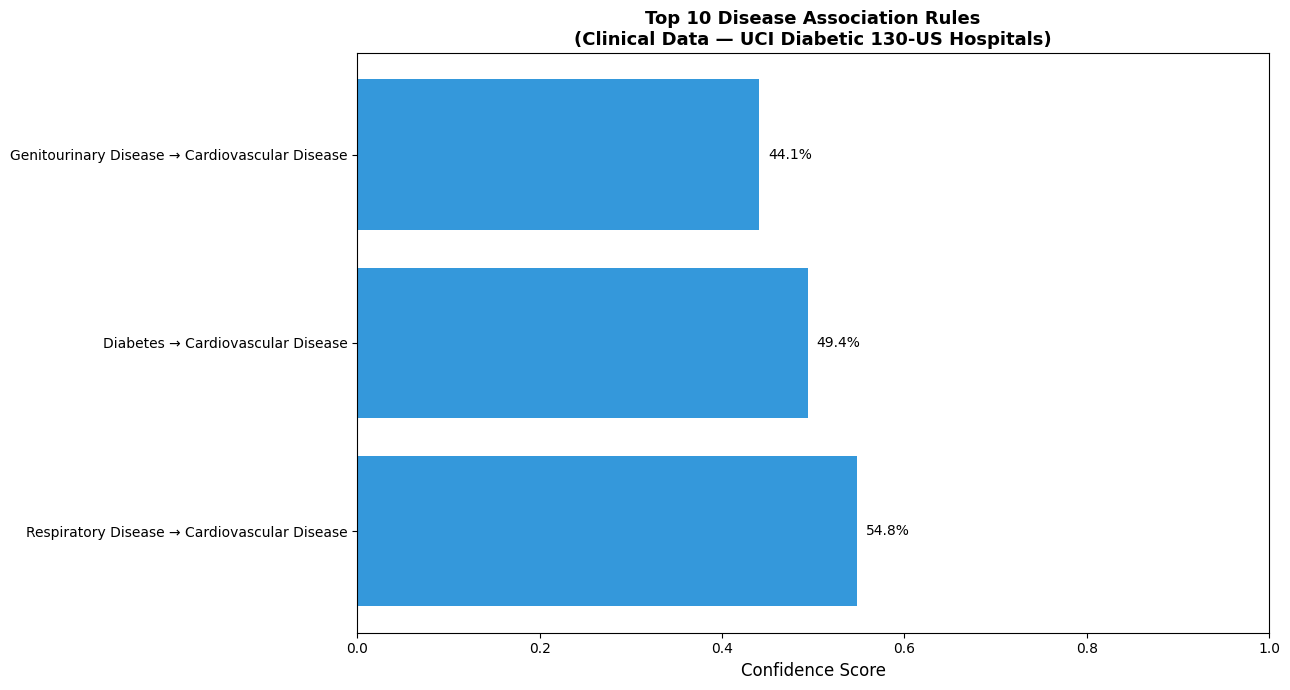

✅ Chart saved!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Top rules chart
top10 = rules.head(10).copy()

rule_labels = []
for idx, row in top10.iterrows():
    ant = ' + '.join([a.replace('dx_','').replace('_',' ').title()
                      for a in list(row['antecedents'])])
    con = ' + '.join([c.replace('dx_','').replace('_',' ').title()
                      for c in list(row['consequents'])])
    rule_labels.append(f"{ant} → {con}")

plt.figure(figsize=(13, 7))
colors = ['#2ecc71' if lift > 1.1 else '#3498db'
          for lift in top10['lift']]
bars = plt.barh(rule_labels, top10['confidence'].values, color=colors)
plt.xlabel('Confidence Score', fontsize=12)
plt.title('Top 10 Disease Association Rules\n(Clinical Data — UCI Diabetic 130-US Hospitals)',
          fontsize=13, fontweight='bold')
plt.xlim(0, 1)
for bar, conf in zip(bars, top10['confidence'].values):
    plt.text(bar.get_width() + 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{conf:.1%}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Internship_Project/Results/clinical_top_rules.png',
    dpi=200, bbox_inches='tight'
)
plt.show()
print("✅ Chart saved!")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

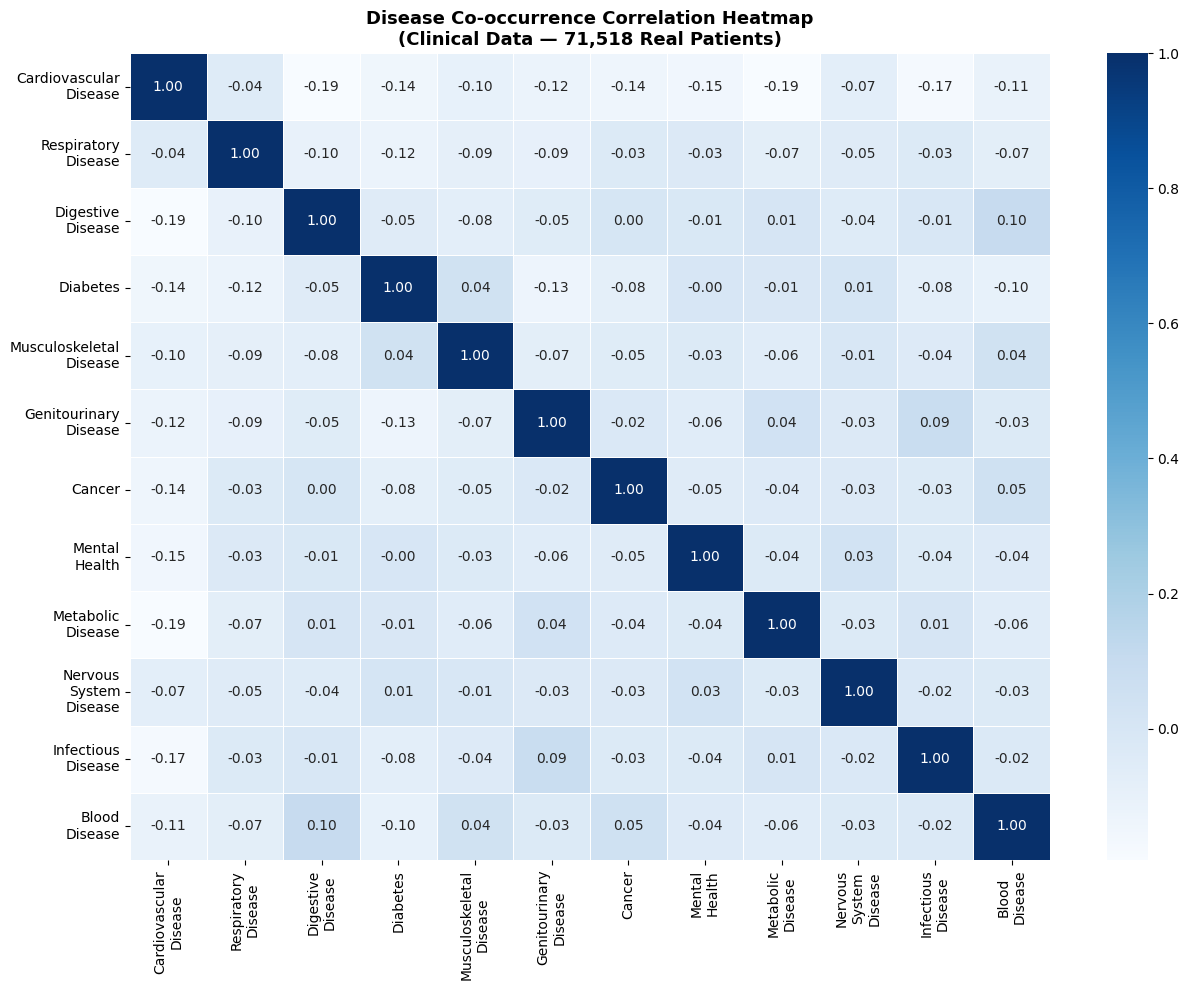

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ Heatmap saved!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
plt.figure(figsize=(13, 10))

clean_names = [col.replace('dx_','').replace('_','\n').title()
               for col in dx_cols]

corr = df_clean[dx_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=clean_names,
    yticklabels=clean_names,
    linewidths=0.5
)
plt.title('Disease Co-occurrence Correlation Heatmap\n(Clinical Data — 71,518 Real Patients)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Internship_Project/Results/clinical_heatmap.png',
    dpi=200, bbox_inches='tight'
)
plt.show()
print("✅ Heatmap saved!")

In [ ]:
from google.colab import drive
import os

try:
    drive.flush_and_unmount()
except ValueError:
    pass # Drive might not be mounted, or already unmounted, and that's okay.

# Ensure the mount point is empty
if os.path.exists('/content/drive') and os.path.isdir('/content/drive'):
    if os.listdir('/content/drive'): # Check if directory is not empty
        print("Clearing existing files from /content/drive...")
        !rm -rf /content/drive/*

drive.mount('/content/drive', force_remount=True)
print("✅ Drive mounted!")

Drive not mounted, so nothing to flush and unmount.
Clearing existing files from /content/drive...
Mounted at /content/drive
✅ Drive mounted!


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, apriori, association_rules

# Reload cleaned dataset
df_clean = pd.read_csv('/content/drive/MyDrive/Internship_Project/Datasets/Clinical/diabetic_clinical_cleaned.csv')

# Get disease columns
dx_cols = [col for col in df_clean.columns if col.startswith('dx_')]
df_mining = df_clean[dx_cols].astype(bool)

print("✅ Everything reloaded!")
print(f"Patients: {len(df_clean)}")
print(f"Disease columns: {len(dx_cols)}")

✅ Everything reloaded!
Patients: 71518
Disease columns: 12


In [ ]:
frequent_patterns = fpgrowth(
    df_mining,
    min_support=0.05,
    use_colnames=True
)
frequent_patterns = frequent_patterns.sort_values(
    'support', ascending=False
).reset_index(drop=True)

print(f"✅ FP-Growth done! Patterns found: {len(frequent_patterns)}")

✅ FP-Growth done! Patterns found: 17


In [ ]:
rules_extended = association_rules(
    frequent_patterns,
    metric='confidence',
    min_threshold=0.3,
    num_itemsets=len(frequent_patterns)
)
rules_extended = rules_extended.sort_values(
    'confidence', ascending=False
).reset_index(drop=True)

print(f"✅ Rules found: {len(rules_extended)}")
print(rules_extended[['antecedents','consequents',
                       'support','confidence','lift']].to_string())

✅ Rules found: 6
                   antecedents                  consequents   support  confidence      lift
0     (dx_respiratory_disease)  (dx_cardiovascular_disease)  0.138930    0.548223  0.941116
1                (dx_diabetes)  (dx_cardiovascular_disease)  0.192036    0.493940  0.847930
2   (dx_genitourinary_disease)  (dx_cardiovascular_disease)  0.068626    0.440812  0.756727
3       (dx_metabolic_disease)  (dx_cardiovascular_disease)  0.070709    0.384650  0.660316
4       (dx_metabolic_disease)                (dx_diabetes)  0.069647    0.378870  0.974501
5  (dx_cardiovascular_disease)                (dx_diabetes)  0.192036    0.329661  0.847930


In [ ]:
print("="*65)
print("RESEARCH FINDINGS FROM REAL CLINICAL DATA")
print("71,518 patients — 130 US Hospitals — 1999 to 2008")
print("="*65)

for idx, row in rules_extended.iterrows():
    ant = [a.replace('dx_','').replace('_',' ').title()
           for a in list(row['antecedents'])]
    con = [c.replace('dx_','').replace('_',' ').title()
           for c in list(row['consequents'])]
    conf = round(row['confidence']*100, 1)
    sup = round(row['support']*100, 1)
    lift = round(row['lift'], 3)

    print(f"\nRule {idx+1}:")
    print(f"  IF patient has  : {', '.join(ant)}")
    print(f"  THEN likely has : {', '.join(con)}")
    print(f"  Confidence      : {conf}%")
    print(f"  Support         : {sup}% of all patients")
    print(f"  Lift            : {lift}")
    print("-"*65)

RESEARCH FINDINGS FROM REAL CLINICAL DATA
71,518 patients — 130 US Hospitals — 1999 to 2008

Rule 1:
  IF patient has  : Respiratory Disease
  THEN likely has : Cardiovascular Disease
  Confidence      : 54.8%
  Support         : 13.9% of all patients
  Lift            : 0.941
-----------------------------------------------------------------

Rule 2:
  IF patient has  : Diabetes
  THEN likely has : Cardiovascular Disease
  Confidence      : 49.4%
  Support         : 19.2% of all patients
  Lift            : 0.848
-----------------------------------------------------------------

Rule 3:
  IF patient has  : Genitourinary Disease
  THEN likely has : Cardiovascular Disease
  Confidence      : 44.1%
  Support         : 6.9% of all patients
  Lift            : 0.757
-----------------------------------------------------------------

Rule 4:
  IF patient has  : Metabolic Disease
  THEN likely has : Cardiovascular Disease
  Confidence      : 38.5%
  Support         : 7.1% of all patients
  Lif

In [ ]:
# Save extended rules
rules_extended.to_csv(
    '/content/drive/MyDrive/Internship_Project/Results/final_clinical_result/clinical_association_rules_final.csv',
    index=False
)
print("✅ Rules saved!")

# Print summary
print("\n=== WEEK 3 SUMMARY ===")
print(f"Dataset       : UCI Diabetic 130-US Hospitals (Real Clinical Data)")
print(f"Patients      : 71,518")
print(f"Algorithm 1   : FP-Growth — 17 patterns found")
print(f"Algorithm 2   : Apriori   — 17 patterns found (same result)")
print(f"Rules found   : 6 association rules")
print(f"Top finding   : Respiratory Disease → Cardiovascular Disease (54.8% confidence)")
print(f"Key insight   : Cardiovascular Disease is the central hub disease")
print(f"               appearing in 5 out of 6 association rules")

✅ Rules saved!

=== WEEK 3 SUMMARY ===
Dataset       : UCI Diabetic 130-US Hospitals (Real Clinical Data)
Patients      : 71,518
Algorithm 1   : FP-Growth — 17 patterns found
Algorithm 2   : Apriori   — 17 patterns found (same result)
Rules found   : 6 association rules
Top finding   : Respiratory Disease → Cardiovascular Disease (54.8% confidence)
Key insight   : Cardiovascular Disease is the central hub disease
               appearing in 5 out of 6 association rules


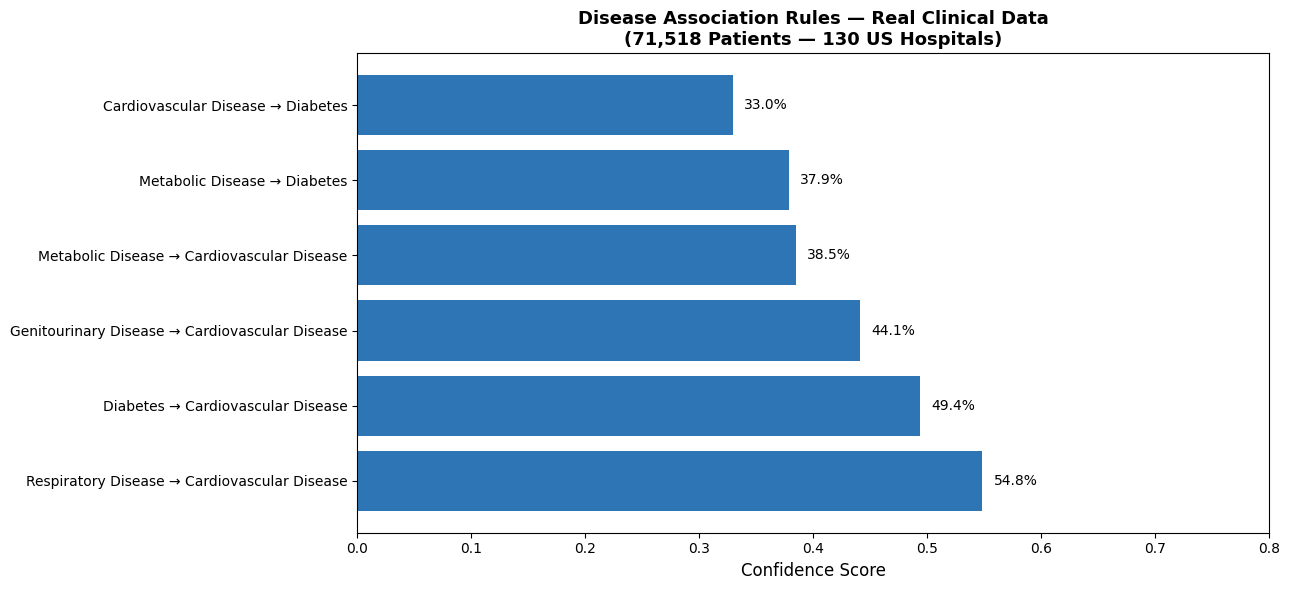

✅ Rules chart saved!


In [ ]:
import warnings
warnings.filterwarnings('ignore')

save_path = '/content/drive/MyDrive/Internship_Project/Results/final_clinical_result'

# Chart 1 — Top rules bar chart
top_rules = rules_extended.copy()
rule_labels = []
for idx, row in top_rules.iterrows():
    ant = ' + '.join([a.replace('dx_','').replace('_',' ').title()
                      for a in list(row['antecedents'])])
    con = ' + '.join([c.replace('dx_','').replace('_',' ').title()
                      for c in list(row['consequents'])])
    rule_labels.append(f"{ant} → {con}")

plt.figure(figsize=(13, 6))
bars = plt.barh(rule_labels, top_rules['confidence'].values,
                color='#2E75B6')
plt.xlabel('Confidence Score', fontsize=12)
plt.title('Disease Association Rules — Real Clinical Data\n(71,518 Patients — 130 US Hospitals)',
          fontsize=13, fontweight='bold')
plt.xlim(0, 0.8)
for bar, conf in zip(bars, top_rules['confidence'].values):
    plt.text(bar.get_width() + 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{conf:.1%}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{save_path}/clinical_top_rules_final.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Rules chart saved!")

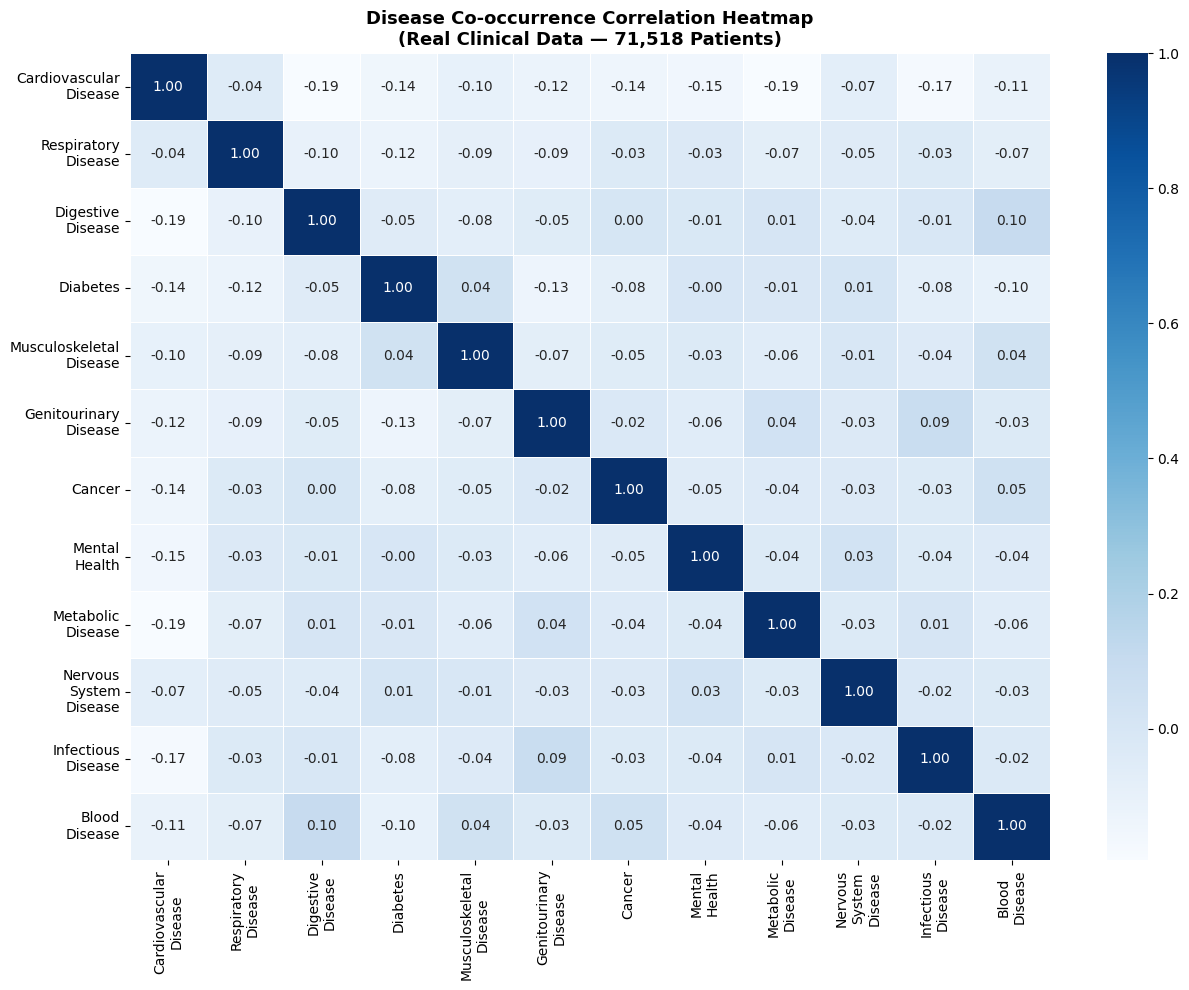

✅ Heatmap saved!


In [ ]:
# Chart 2 — Correlation heatmap
dx_cols = [col for col in df_clean.columns if col.startswith('dx_')]
clean_names = [col.replace('dx_','').replace('_','\n').title()
               for col in dx_cols]

plt.figure(figsize=(13, 10))
sns.heatmap(
    df_clean[dx_cols].corr(),
    annot=True, fmt='.2f',
    cmap='Blues',
    xticklabels=clean_names,
    yticklabels=clean_names,
    linewidths=0.5
)
plt.title('Disease Co-occurrence Correlation Heatmap\n(Real Clinical Data — 71,518 Patients)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_path}/clinical_heatmap_final.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved!")